# 10 — Final Analysis

Synthesizes the project's exploratory, statistical, and modeling results into a single report: crime and weather patterns, model performance, feature importance, error behavior, and the weather ablation study.

**Inputs.** `data/interim/crime_daily.parquet`; `outputs/tables/correlation_results.csv`, `statistical_test_results.csv`, `weather_group_comparisons.csv`, `community_weather_associations.csv`, `crime_weather_summary.csv` (notebook 06); `model_comparison.csv`, `cv_summary.csv` (notebook 08); `feature_importance.csv`, `error_analysis_by_community.csv`, `weather_ablation.csv`, `weather_ablation_robustness.csv`, `ablation_significance_tests.csv`, `rf_test_metrics.csv` (notebook 09).

**Outputs.** `outputs/tables/final_model_comparison.csv`; `outputs/figures/final/citywide_crime_trend.png`, `top_community_areas.png`, `model_comparison_final.png`, `weather_ablation_final.png`.

## 02 — Environment & Imports

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 130)

from src import config

CRIME_DAILY_PATH = config.DATA_INTERIM / "crime_daily.parquet"
TABLE_DIR = config.OUTPUTS_DIR / "tables"
FINAL_FIG_DIR = config.OUTPUTS_DIR / "figures" / "final"
FINAL_FIG_DIR.mkdir(parents=True, exist_ok=True)

## 03 — Load & Validate

Confirms all required inputs listed above are present before the analysis begins.

In [2]:
REQUIRED_FILES = [
    (CRIME_DAILY_PATH, "03_spatiotemporal_feature_engineering"),
    (TABLE_DIR / "correlation_results.csv", "06_crime_weather_analysis"),
    (TABLE_DIR / "statistical_test_results.csv", "06_crime_weather_analysis"),
    (TABLE_DIR / "weather_group_comparisons.csv", "06_crime_weather_analysis"),
    (TABLE_DIR / "community_weather_associations.csv", "06_crime_weather_analysis"),
    (TABLE_DIR / "crime_weather_summary.csv", "06_crime_weather_analysis"),
    (TABLE_DIR / "model_comparison.csv", "08_model_training_and_comparison"),
    (TABLE_DIR / "cv_summary.csv", "08_model_training_and_comparison"),
    (TABLE_DIR / "feature_importance.csv", "09_model_interpretation"),
    (TABLE_DIR / "error_analysis_by_community.csv", "09_model_interpretation"),
    (TABLE_DIR / "weather_ablation.csv", "09_model_interpretation"),
    (TABLE_DIR / "weather_ablation_robustness.csv", "09_model_interpretation (Section 11b)"),
    (TABLE_DIR / "ablation_significance_tests.csv", "09_model_interpretation (Section 11b)"),
    (TABLE_DIR / "rf_test_metrics.csv", "09_model_interpretation (Section 05)"),
]

missing = [(p, producer) for p, producer in REQUIRED_FILES if not p.exists()]
if missing:
    lines = "\n".join(f"  - {p} (run {producer}.ipynb)" for p, producer in missing)
    raise FileNotFoundError(f"{len(missing)} required file(s) missing:\n{lines}")

print(f"All {len(REQUIRED_FILES)} required upstream files present.")

All 14 required upstream files present.


## 04 — Citywide Crime Trend, 2021-2025

Total crime volume across all 77 community areas, by month, over the five-year window.

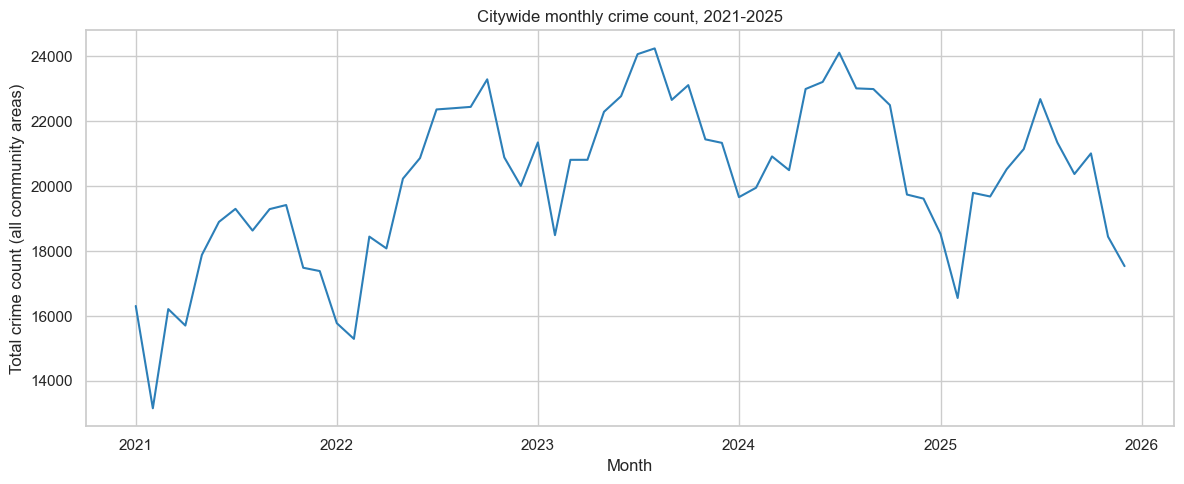

year
2021    209688
2022    240110
2023    263409
2024    259223
2025    237629
Name: crime_count, dtype: int64

In [3]:
crime_daily_df = pd.read_parquet(CRIME_DAILY_PATH)
crime_daily_df["date"] = pd.to_datetime(crime_daily_df["date"])

citywide_daily = crime_daily_df.groupby("date", as_index=False)["crime_count"].sum()
citywide_monthly = citywide_daily.set_index("date")["crime_count"].resample("MS").sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(citywide_monthly["date"], citywide_monthly["crime_count"], color="#2c7fb8")
ax.set_title("Citywide monthly crime count, 2021-2025")
ax.set_xlabel("Month")
ax.set_ylabel("Total crime count (all community areas)")
plt.tight_layout()
fig.savefig(FINAL_FIG_DIR / "citywide_crime_trend.png", dpi=120, bbox_inches="tight")
plt.show()

yearly_totals = citywide_monthly.assign(year=citywide_monthly["date"].dt.year).groupby("year")["crime_count"].sum()
yearly_totals

Citywide crime rose from 209,688 incidents in 2021 to a peak of 263,409 in 2023, then declined to 259,223 (2024) and 237,629 (2025). This turning point matches the `high_crime_day` target rate, which peaks in the same year (32.4% in 2023, against 15.7% in 2021 and 24.5% in 2025) — two independently computed measures confirming the same peak.

## 05 — Crime Concentration by Community Area

Total crime volume by community area, and the same top areas broken out by year to show whether concentration is stable or shifting.

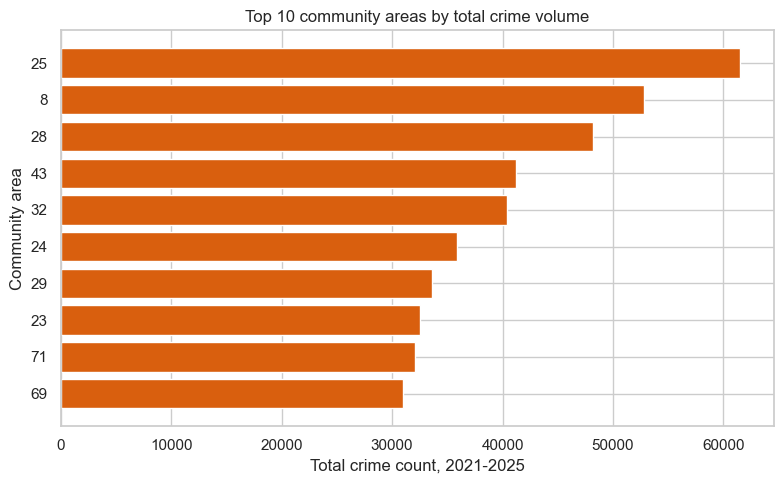

,community_area,crime_count
24,25,61512
7,8,52854
27,28,48228
42,43,41258
31,32,40397
23,24,35852
28,29,33653
22,23,32488
70,71,32056
68,69,31027


In [4]:
area_totals = crime_daily_df.groupby("community_area", as_index=False)["crime_count"].sum().sort_values("crime_count", ascending=False)
top10_areas = area_totals.head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ordered = top10_areas.iloc[::-1]
ax.barh(ordered["community_area"].astype(str), ordered["crime_count"], color="#d95f0e")
ax.set_xlabel("Total crime count, 2021-2025")
ax.set_ylabel("Community area")
ax.set_title("Top 10 community areas by total crime volume")
plt.tight_layout()
fig.savefig(FINAL_FIG_DIR / "top_community_areas.png", dpi=120, bbox_inches="tight")
plt.show()
top10_areas

In [5]:
top5_area_ids = top10_areas["community_area"].head(5).tolist()
top5_by_year = (
    crime_daily_df[crime_daily_df["community_area"].isin(top5_area_ids)]
    .assign(year=crime_daily_df["date"].dt.year)
    .groupby(["community_area", "year"])["crime_count"].sum()
    .unstack("year")
)
top5_by_year

year,2021,2022,2023,2024,2025
community_area,,,,,
8,8406,10655,11198,11436,11159
25,11760,12297,12701,12955,11799
28,6964,9540,10424,10979,10321
32,5612,8068,8810,9327,8580
43,7482,8340,8791,8523,8122


Crime is concentrated in a small set of areas: community area 25 leads with 61,512 total incidents (2021-2025), followed by area 8 (52,854), area 28 (48,228), area 43 (41,258), and area 32 (40,397). The top 5 areas hold the same ranking in every year.

Their year-over-year trajectories diverge slightly from the citywide pattern: areas 8, 25, 28, and 32 each peak in 2024, one year after the citywide 2023 peak, before declining in 2025. Area 43 is the exception, peaking in 2023 alongside the citywide trend.

## 06 — Crime Category Composition: An Open Discrepancy

Notebook 04 reports a category mix of violent 40.7%, property 34.8%, drug 14.9%, fraud 9.5%, on an implied base of roughly 18,000 incidents. Notebook 06, computed on the full 1,210,059-incident cleaned dataset, gives violent 31.2%, property 47.2%, drug 2.4%, other 19.1%.

Notebook 06's figures are treated as authoritative here — they sum to the full cleaned dataset exactly — but the two have not been formally reconciled. This report cites 31.2% / 47.2% / 2.4% / 19.1% as the working figure.

## 07 — Weather-Crime Association

Full statistics are in `outputs/tables/correlation_results.csv`, `statistical_test_results.csv`, `weather_group_comparisons.csv`, and `community_weather_associations.csv`.

- Citywide, temperature and crime associate at Spearman r = 0.552, season-dependent: Winter r = 0.548, Summer r = 0.083 (not statistically significant).
- Extreme cold is the strongest single weather effect (rank-biserial -0.686); extreme heat is next, and positive (+0.420).
- Violent crime is the most temperature-sensitive category (r = 0.640).
- An OLS model adjusting for season and weekend still finds `avg_temp`, `PRCP`, and `SNOW` significant (R-squared = 0.368) — weather adds information beyond a calendar proxy.
- Per-area Spearman r ranges from 0.013 to 0.371 (mean 0.168), well below the citywide-pooled 0.552 — an aggregation effect, not an error; the citywide figure does not describe a typical single area.
- These are associations, not causal effects.

## 08 — Model Performance: Final Comparison

On validation, Logistic Regression scores highest on F1 (0.492) and is the model the project's F1-based selection rule chooses; tuned Random Forest has the best ROC-AUC (0.587) and PR-AUC (0.402) of all five candidates, with a lower F1 (0.473). Under 5-fold chronological cross-validation, default Random Forest's single-split F1 of 0.419 falls to 0.104 +/- 0.107 — the single split overstated its performance; tuning recovers it to 0.326.

On test, Logistic Regression predicts positive on 99.9% of rows (negative-class recall 0.00, accuracy 0.281 — below the majority-class baseline). Random Forest retains real discrimination on both classes (F1 0.425, ROC-AUC 0.589, negative-class recall 0.40) and is the model this project treats as primary.

In [6]:
model_comparison_df = pd.read_csv(TABLE_DIR / "model_comparison.csv")
rf_test_metrics_df = pd.read_csv(TABLE_DIR / "rf_test_metrics.csv")

final_model_comparison_df = (
    pd.concat([model_comparison_df, rf_test_metrics_df], ignore_index=True)
    .drop_duplicates(subset=["model", "split"], keep="last")
    .sort_values(["split", "model"])
    .reset_index(drop=True)
)
final_model_comparison_df.to_csv(TABLE_DIR / "final_model_comparison.csv", index=False)
print(f"saved -> {TABLE_DIR / 'final_model_comparison.csv'}")
final_model_comparison_df

saved -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\final_model_comparison.csv


,model,split,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,test,0.280722,0.278748,0.998850,0.435861,0.548098,0.314809
1,Random Forest (tuned),test,0.482847,0.307727,0.687444,0.425144,0.588559,0.367865
2,Baseline (Dummy),validation,0.675538,0.000000,0.000000,0.000000,0.500000,0.324462
3,Decision Tree,validation,0.497812,0.356391,0.679680,0.467597,0.564005,0.376356
4,Logistic Regression,validation,0.347198,0.328896,0.972585,0.491562,0.582486,0.396772
5,Random Forest (default),validation,0.573101,0.375119,0.474175,0.418870,0.570815,0.390757
6,Random Forest (tuned),validation,0.491123,0.356355,0.705012,0.473417,0.586696,0.402347


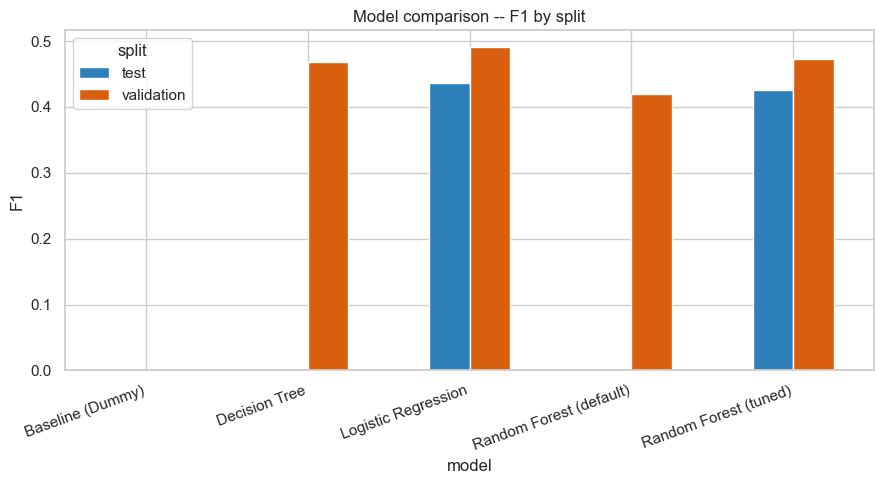

In [7]:
plot_df = final_model_comparison_df.pivot(index="model", columns="split", values="f1")
fig, ax = plt.subplots(figsize=(9, 5))
plot_df.plot(kind="bar", ax=ax, color=["#2c7fb8", "#d95f0e"])
ax.set_ylabel("F1")
ax.set_title("Model comparison -- F1 by split")
ax.legend(title="split")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig(FINAL_FIG_DIR / "model_comparison_final.png", dpi=120, bbox_inches="tight")
plt.show()

The merged table confirms these figures exactly. On test, Random Forest (tuned) reaches accuracy 0.483, F1 0.425, ROC-AUC 0.589; Logistic Regression reaches accuracy 0.281, F1 0.436, ROC-AUC 0.548. Logistic Regression's F1 looks close to Random Forest's only because it is inflated by predicting positive on nearly every row — ROC-AUC and negative-class recall (notebook 09, Section 05) are the more informative comparison. On validation, Random Forest has the best ROC-AUC and PR-AUC of all five candidates; Logistic Regression has the best F1, the metric the selection rule used. The rule and the more robust metrics point to different models.

## 09 — Feature Importance and Error Analysis

- Calendar position drives most of Random Forest's splits: `week_of_year`, `year`, and `month` combined account for roughly 46% of total importance. `avg_temp` is the leading weather feature; `is_extreme_cold` is the only weather flag in the top six.
- Error is uneven across community areas: the 10 weakest (26, 44, 1, 49, 2, 4, 10, 67, 66, 77) show error rates of 56%-60%, against 48% overall.
- Error follows a seasonal cycle: January-April shows 17%-30% error, composed entirely of false negatives; May-December shows 53%-78% error, composed almost entirely of false positives. This repeats across both 2024 and 2025.
- Extreme-cold and snow days (winter) show markedly lower error; extreme-heat days (summer) show markedly higher error — consistent with the seasonal pattern above.

In [8]:
feature_importance_df = pd.read_csv(TABLE_DIR / "feature_importance.csv")
error_by_community_df = pd.read_csv(TABLE_DIR / "error_analysis_by_community.csv")

print("Top 5 features by importance:")
print(feature_importance_df.head(5).to_string(index=False))
print()
print("5 weakest community areas by error rate:")
print(error_by_community_df.sort_values("error_rate", ascending=False).head(5).to_string(index=False))

Top 5 features by importance:
     feature  importance
week_of_year    0.183521
        year    0.153961
       month    0.123537
    avg_temp    0.098606
     quarter    0.088578

5 weakest community areas by error rate:
 community_area  n_rows  n_positive  false_negatives  false_positives  fn_rate  error_rate
             26     731          74               24              418 0.324324    0.604651
             44     731         116               43              392 0.370690    0.595075
              1     731         243              100              327 0.411523    0.584131
             49     731         116               36              388 0.310345    0.580027
              2     731         140               45              374 0.321429    0.573187


## 10 — Does Weather Improve Predictive Performance?

Adding weather to calendar and historical crime features raises ROC-AUC from 0.548 +/- 0.020 to 0.563 +/- 0.014 and PR-AUC from 0.261 +/- 0.087 to 0.270 +/- 0.086, under the tuned Random Forest configuration and 5-fold chronological cross-validation. F1 does not move (0.329 to 0.316, within noise). The tested interaction terms add no further gain on any metric.

A fourth arm isolates weather from calendar entirely: crime and weather features with no calendar columns.

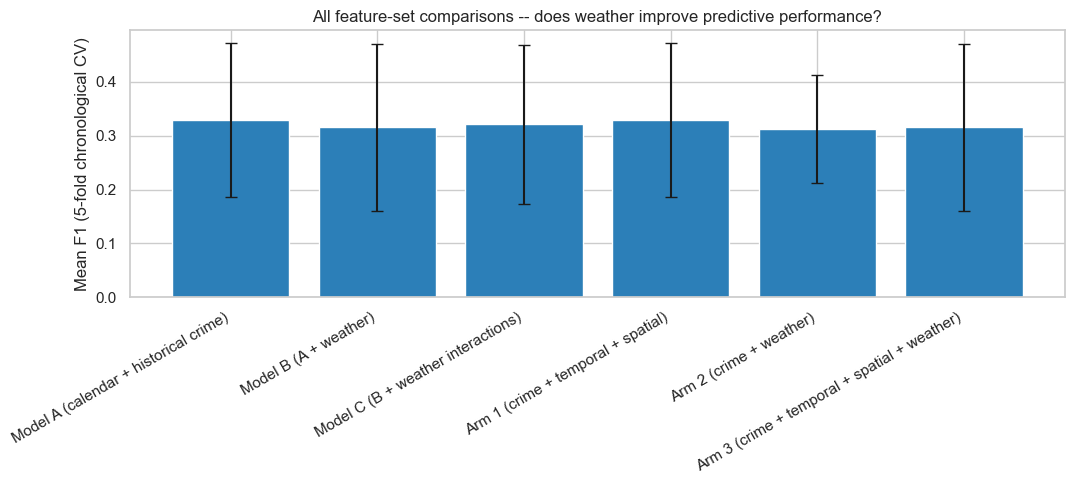

,comparison,metric,n_folds,mean_diff,folds_favoring_b,wilcoxon_statistic,p_value
0,Arm 3 (crime + temporal + spatial + weather) v...,f1,5,-0.0127,2,3.0,0.3125
1,Arm 3 (crime + temporal + spatial + weather) v...,roc_auc,5,0.0156,5,0.0,0.0625
2,Arm 3 (crime + temporal + spatial + weather) v...,f1,5,0.0031,3,6.0,0.8125
3,Arm 3 (crime + temporal + spatial + weather) v...,roc_auc,5,0.0019,3,4.0,0.4375
4,Arm 2 (crime + weather) vs Arm 1 (crime + temp...,f1,5,-0.0158,2,6.0,0.8125
5,Arm 2 (crime + weather) vs Arm 1 (crime + temp...,roc_auc,5,0.0137,5,0.0,0.0625


In [9]:
ablation_df = pd.read_csv(TABLE_DIR / "weather_ablation.csv")
robustness_df = pd.read_csv(TABLE_DIR / "weather_ablation_robustness.csv").rename(columns={"arm": "model"})
combined_ablation_df = pd.concat([ablation_df, robustness_df], ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(combined_ablation_df["model"], combined_ablation_df["f1_mean"], yerr=combined_ablation_df["f1_std"], capsize=4, color="#2c7fb8")
ax.set_ylabel("Mean F1 (5-fold chronological CV)")
ax.set_title("All feature-set comparisons -- does weather improve predictive performance?")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig.savefig(FINAL_FIG_DIR / "weather_ablation_final.png", dpi=120, bbox_inches="tight")
plt.show()

significance_df = pd.read_csv(TABLE_DIR / "ablation_significance_tests.csv")
significance_df

Weather alone reaches ROC-AUC 0.562 +/- 0.015 — statistically indistinguishable from the full feature set's 0.563 +/- 0.014 (3 of 5 folds favor the full set, p = 0.4375). Calendar alone trails at 0.548 +/- 0.020. The paired test shows weather driving the gain: adding weather to calendar wins in all 5 folds (p = 0.0625, the strongest signal available at this sample size), and weather alone beats calendar alone by nearly the same margin, also 5 of 5 folds. Adding calendar on top of weather adds almost nothing. F1 shows no equivalent pattern across any of the three arms.

This nuances the feature-importance result in Section 09, where calendar features rank far above any weather feature. Impurity-based importance measures what the model uses to fit training data; it does not measure what generalizes best across held-out folds. Both results hold at once — they answer different questions.

## 11 — Final Outputs Manifest

Confirms every table and figure this notebook produces is present on disk.

In [10]:
final_outputs = [
    FINAL_FIG_DIR / "citywide_crime_trend.png",
    FINAL_FIG_DIR / "top_community_areas.png",
    FINAL_FIG_DIR / "model_comparison_final.png",
    FINAL_FIG_DIR / "weather_ablation_final.png",
    TABLE_DIR / "final_model_comparison.csv",
]
for path in final_outputs:
    if not path.exists():
        raise FileNotFoundError(f"expected final output missing: {path}")
    print(f"verified -> {path}")

verified -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\figures\final\citywide_crime_trend.png
verified -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\figures\final\top_community_areas.png
verified -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\figures\final\model_comparison_final.png
verified -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\figures\final\weather_ablation_final.png
verified -> C:\Users\Tarankit\Documents\Code\spatial-temporal-crime-trajectory-analytics\outputs\tables\final_model_comparison.csv


## 12 — Limitations

- Crime data is reported and police-recorded, not a census of all actual crime.
- Classifications and records can change over time as cases are investigated or reclassified.
- Location is generalized to block level, not exact coordinates.
- Weather is approximated citywide from a single O'Hare station; no community area's weather is measured directly.
- `high_crime_day` is an analytical construct built for this project, not an official city classification.
- The weather-crime relationship demonstrated here is an observational association, not a causal claim.
- Crime patterns drift over time (target rate: 15.7% in 2021 to 32.4% in 2023 to 24.5% in 2025) — a real risk to model stability that the chronological split is designed to expose, not eliminate.
- Random Forest's predictions rely more on calendar position than on an area's own crime history (Section 09), and its errors follow a seasonal pattern rather than being evenly distributed — a limitation on how far its "high crime day" predictions should be trusted for any single date.
- The crime-category composition discrepancy between notebooks 04 and 06 (Section 06) remains unreconciled.

## 13 — Findings

**1. What crime types dominate?** Open discrepancy (Section 06). Working figure: violent 31.2%, property 47.2%, drug 2.4%, other 19.1% (notebook 06, full cleaned dataset), cited over notebook 04's smaller-base figures.

**2. When does crime peak or decline?** Crime rose from 2021 to a 2023 peak (263,409 citywide incidents), then declined through 2024 and 2025 (237,629). This matches the `high_crime_day` target-rate peak in notebook 07 — an independent confirmation of the same turning point.

**3. Where is crime concentrated?** Community area 25 has the highest total volume (61,512 incidents), followed by areas 8, 28, 43, and 32. The top 5 hold a stable ranking across all five years.

**4. How do spatial patterns change over time?** Four of the top 5 areas (8, 25, 28, 32) peak in 2024, one year after the citywide peak; area 43 peaks in step with the city, in 2023. A full spatial-temporal treatment across all 77 areas is notebook 04's responsibility.

**5. Which weather conditions associate with crime?** Extreme cold is the strongest single weather effect (rank-biserial -0.686); extreme heat is next (+0.420). Temperature's association with crime is season-dependent (Winter r=0.548, Summer not significant). Violent crime is the most temperature-sensitive category (r=0.640).

**6. Does weather improve predictive performance?** Yes, modestly, in ROC-AUC (0.548 to 0.563) and PR-AUC (0.261 to 0.270), not in F1. Isolating weather from calendar shows weather alone (ROC-AUC 0.562) accounts for nearly all of that gain — statistically indistinguishable from the full feature set (0.563) and clearly ahead of calendar alone (0.548, 5 of 5 CV folds, p = 0.0625).

**7. Can high-crime community-days be classified reliably?** Not reliably in an absolute sense, but genuinely better than chance. Random Forest reaches F1 0.425 and ROC-AUC 0.589 on test, retaining discrimination on both classes. Logistic Regression, the model the project's F1 rule selected, fails this test on held-out data.

**8. Which features matter most?** Calendar position (`week_of_year`, `year`, `month`, roughly 46% of importance combined), then `avg_temp`, then historical-crime rolling averages and `is_extreme_cold`. Feature importance is not a causal ranking.

**9. Where does the model err?** Unevenly across 10 community areas, and on a seasonal cycle — false negatives dominate winter/spring, false positives dominate summer/fall, repeating across both test years.

**10. Major limitations?** See Section 12.

## Overall Conclusion

Weather associates with crime in a real, non-trivial way (Section 07) and is the primary source of the model's predictive edge beyond calendar and historical crime features (Section 10): weather alone reaches ROC-AUC 0.562, within noise of the full feature set's 0.563, while calendar alone trails at 0.548. The improvement is confined to ranking quality (ROC-AUC, PR-AUC), not F1, and the tested interaction terms add nothing further.

Random Forest is a defensible, if modest, classifier for `high_crime_day` — it holds up on test where Logistic Regression, the model the project's F1-based selection rule chose, does not (Logistic Regression's higher test F1 is inflated by predicting positive on 99.9% of rows). Random Forest's feature importance leans heavily on calendar position, producing a season-linked error pattern (Section 09): false negatives dominate winter and spring, false positives dominate summer and fall, repeating across both test years. The robustness check nuances this: calendar dominates what the model uses to split nodes, but weather alone matches the full model's out-of-fold ranking quality — different questions, both answered.

Crime volume peaked citywide in 2023 and has declined for two years since, matching the `high_crime_day` target-rate peak (notebook 07). Crime is concentrated in a stable set of top areas led by area 25, most of which peaked a year after the citywide trend, in 2024.

Two items remain open: reconciling the crime-category composition discrepancy between notebooks 04 and 06 (Section 06), and extracting the duplicated chronological-fold and metrics logic from notebooks 08 and 09 into `src/modeling/`, as noted in `PROJECT_STATUS_HANDOFF.md`.